# Supervised Learning Model Evaluation Lab

Complete the exercises below to solidify your knowledge and understanding of supervised learning model evaluation.

In [6]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

## Regression Model Evaluation

In [7]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
data = pd.read_csv('housing.csv', header=None, delimiter=r"\s+", names=column_names)

In [8]:
"""
CRIM - per capita crime rate by town
ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS - proportion of non-retail business acres per town.
CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
NOX - nitric oxides concentration (parts per 10 million)
RM - average number of rooms per dwelling
AGE - proportion of owner-occupied units built prior to 1940
DIS - weighted distances to five Boston employment centres
RAD - index of accessibility to radial highways
TAX - full-value property-tax rate per $10,000
PTRATIO - pupil-teacher ratio by town
B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
LSTAT - % lower status of the population
MEDV - Median value of owner-occupied homes in $1000's"""

"\nCRIM - per capita crime rate by town\nZN - proportion of residential land zoned for lots over 25,000 sq.ft.\nINDUS - proportion of non-retail business acres per town.\nCHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)\nNOX - nitric oxides concentration (parts per 10 million)\nRM - average number of rooms per dwelling\nAGE - proportion of owner-occupied units built prior to 1940\nDIS - weighted distances to five Boston employment centres\nRAD - index of accessibility to radial highways\nTAX - full-value property-tax rate per $10,000\nPTRATIO - pupil-teacher ratio by town\nB - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town\nLSTAT - % lower status of the population\nMEDV - Median value of owner-occupied homes in $1000's"

In [9]:
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


## 1. Split this data set into training (80%) and testing (20%) sets.

The `MEDV` field represents the median value of owner-occupied homes (in $1000's) and is the target variable that we will want to predict.

In [12]:
from sklearn.model_selection import train_test_split

X = data.drop('MEDV',axis =1)

y = data['MEDV']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (404, 13)
X_test shape: (102, 13)
y_train shape: (404,)
y_test shape: (102,)


## 2. Train a `LinearRegression` model on this data set and generate predictions on both the training and the testing set.

In [14]:
from sklearn.linear_model import LinearRegression

regr = LinearRegression()

regr.fit(X_train, y_train)

y_train_pred = regr.predict(X_train)

y_test_pred = regr.predict(X_test)

print("Training predictions:", y_train_pred[:5])
print("Testing predictions:", y_test_pred[:5])

Training predictions: [10.96952405 19.41196567 23.06419602 12.1470648  18.3738116 ]
Testing predictions: [28.99672362 36.02556534 14.81694405 25.03197915 18.76987992]


## 3. Calculate and print R-squared for both the training and the testing set.

In [15]:
from sklearn.metrics import r2_score

# R² for training data
r2_train = r2_score(y_train, y_train_pred)

# R² for testing data
r2_test = r2_score(y_test, y_test_pred)

print("Training R²:", r2_train)
print("Testing R²:", r2_test)

Training R²: 0.7508856358979673
Testing R²: 0.6687594935356317


## 4. Calculate and print mean squared error for both the training and the testing set.

In [16]:
from sklearn.metrics import mean_squared_error

# MSE for training data
mse_train = mean_squared_error(y_train, y_train_pred)

# MSE for testing data
mse_test = mean_squared_error(y_test, y_test_pred)

print("Training MSE:", mse_train)
print("Testing MSE:", mse_test)

Training MSE: 21.641412753226312
Testing MSE: 24.291119474973538


## 5. Calculate and print mean absolute error for both the training and the testing set.

In [17]:
from sklearn.metrics import mean_absolute_error

# MAE for training data
mae_train = mean_absolute_error(y_train, y_train_pred)

# MAE for testing data
mae_test = mean_absolute_error(y_test, y_test_pred)

print("Training MAE:", mae_train)
print("Testing MAE:", mae_test)

Training MAE: 3.3147716267832252
Testing MAE: 3.1890919658878416


## Classification Model Evaluation

In [18]:
from sklearn.datasets import load_iris
data = load_iris()

In [19]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [20]:
column_names = data.feature_names

In [21]:
df = pd.DataFrame(data['data'],columns=column_names)

In [22]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [23]:
target = pd.DataFrame(data.target)

In [24]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [28]:

df['class'] = [data['target_names'][i] for i in data.target]

data['target_names']


array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## 6. Split this data set into training (80%) and testing (20%) sets.

The `class` field represents the type of flower and is the target variable that we will want to predict.

In [30]:
from sklearn.model_selection import train_test_split

# Features
X = df.drop('class', axis=1)

# Target
y = df['class']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


## 7. Train a `LogisticRegression` model on this data set and generate predictions on both the training and the testing set.

In [31]:
from sklearn.linear_model import LogisticRegression

# Create the model
logreg = LogisticRegression(max_iter=200)

# Train the model
logreg.fit(X_train, y_train)

# Predictions on training data
y_train_pred = logreg.predict(X_train)

# Predictions on testing data
y_test_pred = logreg.predict(X_test)

print("Training predictions:", y_train_pred[:5])
print("Testing predictions:", y_test_pred[:5])

Training predictions: [np.str_('setosa') np.str_('versicolor') np.str_('versicolor')
 np.str_('setosa') np.str_('versicolor')]
Testing predictions: [np.str_('setosa') np.str_('virginica') np.str_('versicolor')
 np.str_('versicolor') np.str_('setosa')]


## 8. Calculate and print the accuracy score for both the training and the testing set.

In [33]:
from sklearn.metrics import accuracy_score

# Accuracy on training data
accuracy_train = accuracy_score(y_train, y_train_pred)

# Accuracy on testing data
accuracy_test = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", accuracy_train)
print("Testing Accuracy:", accuracy_test)

print("Training Accuracy:", accuracy_train * 100, "%")
print("Testing Accuracy:", accuracy_test * 100, "%")

Training Accuracy: 0.975
Testing Accuracy: 0.9666666666666667
Training Accuracy: 97.5 %
Testing Accuracy: 96.66666666666667 %


## 9. Calculate and print the balanced accuracy score for both the training and the testing set.

In [34]:
from sklearn.metrics import balanced_accuracy_score

# Balanced accuracy on training data
balanced_train = balanced_accuracy_score(y_train, y_train_pred)

# Balanced accuracy on testing data
balanced_test = balanced_accuracy_score(y_test, y_test_pred)

print("Training Balanced Accuracy:", balanced_train)
print("Testing Balanced Accuracy:", balanced_test)

Training Balanced Accuracy: 0.975
Testing Balanced Accuracy: 0.9666666666666667


## 10. Calculate and print the precision score for both the training and the testing set.

In [35]:
from sklearn.metrics import precision_score

# Precision on training data
precision_train = precision_score(y_train, y_train_pred, average='weighted')

# Precision on testing data
precision_test = precision_score(y_test, y_test_pred, average='weighted')

print("Training Precision:", precision_train)
print("Testing Precision:", precision_test)

Training Precision: 0.9751928288513655
Testing Precision: 0.9696969696969696


## 11. Calculate and print the recall score for both the training and the testing set.

In [36]:
from sklearn.metrics import recall_score

# Recall on training data
recall_train = recall_score(y_train, y_train_pred, average='weighted')

# Recall on testing data
recall_test = recall_score(y_test, y_test_pred, average='weighted')

print("Training Recall:", recall_train)
print("Testing Recall:", recall_test)

Training Recall: 0.975
Testing Recall: 0.9666666666666667


## 12. Calculate and print the F1 score for both the training and the testing set.

In [37]:
from sklearn.metrics import f1_score

# F1 score on training data
f1_train = f1_score(y_train, y_train_pred, average='weighted')

# F1 score on testing data
f1_test = f1_score(y_test, y_test_pred, average='weighted')

print("Training F1 Score:", f1_train)
print("Testing F1 Score:", f1_test)

Training F1 Score: 0.9749960931395532
Testing F1 Score: 0.9665831244778613


## 13. Generate confusion matrices for both the training and the testing set.

Training Confusion Matrix:
[[40  0  0]
 [ 0 38  2]
 [ 0  1 39]]

Testing Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


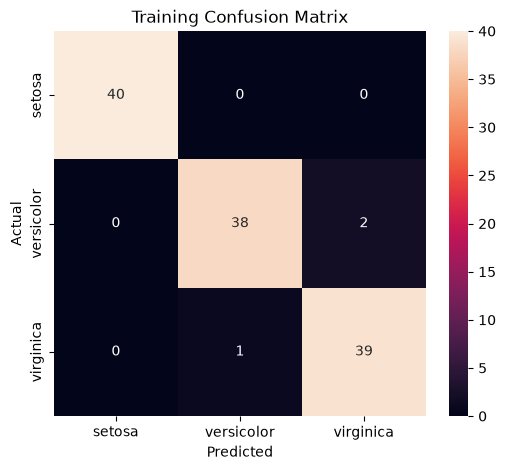

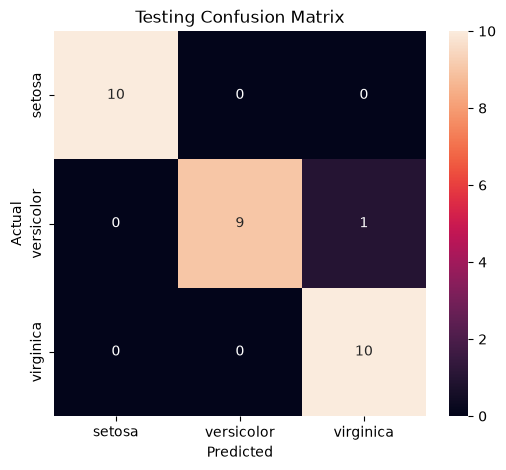

In [40]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix for training data
cm_train = confusion_matrix(y_train, y_train_pred)

# Confusion matrix for testing data
cm_test = confusion_matrix(y_test, y_test_pred)

print("Training Confusion Matrix:")
print(cm_train)

print("\nTesting Confusion Matrix:")
print(cm_test)

# Training confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_train,
    annot=True,
    fmt='d',
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Training Confusion Matrix')
plt.show()


plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Testing Confusion Matrix')
plt.show()



## Bonus: For each of the data sets in this lab, try training with some of the other models you have learned about, recalculate the evaluation metrics, and compare to determine which models perform best on each data set.

In [26]:
# Have fun here !